# Predict Glassdoor Reviews
Use trained models to predict sentiment of Glassdoor Reviews.

## Loading the model

In [1]:
import logging
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import platform
import random
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from transformers import AutoTokenizer, BertTokenizer, BertModel, pipeline

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.FileHandler("predict_metrics.log"), logging.StreamHandler()],
)

In [3]:
RANDOM_SEED = 103
BERTIMBAU_PATH = "neuralmind/bert-base-portuguese-cased"
BERTIMBAU_HIDDEN_SIZE = 768
TOKEN_MAX_LENGTH = 512
N_LABELS = 3

TWITTER_XML_PATH = "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned"

GOLDEN_DATASET_NAME = "golden_glassdoor_reviews.csv"

if platform.system() == "Windows":
    BERTIMBAU_PATH = "C:\\bert-base-portuguese-cased"
else:
    BERTIMBAU_PATH = "/home/stevillis/bert-base-portuguese-cased"

NEUTRAL_SENTIMENT_COLOR = sns.color_palette()[0]
POSITIVE_SENTIMENT_COLOR = sns.color_palette()[2]
NEGATIVE_SENTIMENT_COLOR = sns.color_palette()[1]

SENTIMENT_PALETTE = [
    NEUTRAL_SENTIMENT_COLOR,
    POSITIVE_SENTIMENT_COLOR,
    NEGATIVE_SENTIMENT_COLOR,
]

PLOT_SENTIMENT_LABELS = ["Positivo", "Negativo", "Neutro"]

In [4]:
torch.manual_seed(RANDOM_SEED)

In [5]:
random.seed(RANDOM_SEED)

In [6]:
np.random.seed(RANDOM_SEED)

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"There are {torch.cuda.device_count()} GPU(s) available.")
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")

There are 1 GPU(s) available.
Device name: NVIDIA GeForce GTX 1650


In [8]:
dataset = pd.read_csv(f"./{GOLDEN_DATASET_NAME}")

In [9]:
dataset.head(2)

,review_id,company,employee_role,employee_detail,review_text,review_date,star_rating,sentiment,predicted_sentiment_m1,predicted_sentiment_m2,predicted_sentiment_m3,predicted_sentiment_m4
0,75214861,TOTVS,Consultor De Vendas Sênior,Funcionário(a) atual,Nada a reclamar até o momento.,5 de abr. de 2023,4.0,0,0,0,0,0
1,78733006,TOTVS,Product Owner,"Funcionário(a) atual, mais de 5 anos",Não ha nada que desabone,31 de jul. de 2023,5.0,0,0,0,0,0


In [10]:
dataset.shape

(246, 12)

In [11]:
dataset["sentiment"].value_counts()

sentiment
0    82
1    82
2    82
Name: count, dtype: int64

In [12]:
dataset["company"].value_counts()

company
TOTVS                         230
Sankhya Gestão de Negócios     16
Name: count, dtype: int64

In [13]:
tokenizer = BertTokenizer.from_pretrained(BERTIMBAU_PATH, truncation=True)

### Predict reviews sentiment

In [14]:
def predict_sentiment(review_text, model):
    outputs = []
    encoded_texts = tokenizer(
        review_text,
        max_length=TOKEN_MAX_LENGTH,
        add_special_tokens=True,
        return_token_type_ids=False,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt",
    )

    input_ids = encoded_texts["input_ids"].to(device)
    attention_mask = encoded_texts["attention_mask"].to(device)

    with torch.no_grad():
        output = model(input_ids, attention_mask)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        outputs.append(probabilities.cpu().numpy())

    return np.concatenate(outputs, axis=0)

In [15]:
total_iterations = len(dataset)
total_iterations

246

In [16]:
def predict(model, new_column):
    dataset[new_column] = pd.Series(dtype="int")

    for index, row in tqdm(
        dataset.iterrows(), total=total_iterations, desc="Processing"
    ):

        output_probabilities = predict_sentiment(
            review_text=row["review_text"], model=model
        )

        predicted_sentiment = np.argmax(output_probabilities)
        dataset.loc[index, new_column] = predicted_sentiment

        if index > 0 and index % 100 == 0:
            logging.info(f"Predicted rows: {index}/{total_iterations}")

            logging.info(

                f"\nReview Text: {row['review_text']}\nPredicted Sentiment: {predicted_sentiment}\n\n"
            )

    dataset[new_column] = dataset[new_column].astype(int)

### Model 1 Predictions
#### Model with data augmentation and freezing bert layers

In [17]:
class GlassdoorReviewsClassifier(nn.Module):
    def __init__(self, num_labels, classifier):
        super(GlassdoorReviewsClassifier, self).__init__()

        self.bert = BertModel.from_pretrained(BERTIMBAU_PATH)
        self.classifier = classifier

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs["last_hidden_state"][:, 0, :]
        x = self.classifier(x)
        return x

In [18]:
model1 = GlassdoorReviewsClassifier(
    num_labels=N_LABELS,
    classifier=nn.Sequential(
        nn.Linear(BERTIMBAU_HIDDEN_SIZE, 300),
        nn.ReLU(),
        nn.Linear(300, 100),
        nn.ReLU(),
        nn.Linear(100, 50),
        nn.ReLU(),
        nn.Linear(50, N_LABELS),
    ),
).to(device)

In [19]:
model1.load_state_dict(
    torch.load(
        "../train_model/bertimbau-glassdoor-reviews-oversampled-freezing-v1.bin",
        map_location=device,
    )
)
model1.eval();

In [20]:
predict(model=model1, new_column="predicted_sentiment_m1")

Processing:   0%|          | 0/246 [00:00<?, ?it/s]c:\venvs\venv_sent_analysis\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Processing:  40%|████      | 99/246 [00:09<00:12, 11.51it/s]2025-04-15 03:43:32,503 [INFO] Predicted rows: 100/246
2025-04-15 03:43:32,530 [INFO] 
Review Text: Salario acima da média, ótimos benefícios
Predicted Sentiment: 1


Processing:  81%|████████  | 199/246 [00:18<00:04, 11.45it/s]2025-04-15 03:43:41,203 [INFO] Predicted rows: 200/246
2025-04-15 03:43:41,206 [INFO] 
Review Text: Não há reconhecimento dos funcionários, não existe política de cargos e salários, novos funcionários chegam a ganhar o dobro de funcionários com mais de 5 anos de casa na mesma função. Pessoas com graus de parentesco em condição de subordinados/chefia dire

In [21]:
dataset["predicted_sentiment_m1"].value_counts()

predicted_sentiment_m1
0    85
1    85
2    76
Name: count, dtype: int64

### Model 2 Predictions

#### Model with data augmentation, freezing bert layers and dropout

In [22]:
model2 = GlassdoorReviewsClassifier(
    num_labels=N_LABELS,
    classifier=nn.Sequential(
        nn.Linear(BERTIMBAU_HIDDEN_SIZE, 300),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(300, 100),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(100, 50),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(50, N_LABELS),
    ),
).to(device)

In [23]:
model2.load_state_dict(
    torch.load(
        "../train_model/bertimbau-glassdoor-reviews-dropout-oversampled-freezing.bin",
        map_location=device,
    )
)
model2.eval();

In [24]:
predict(model=model2, new_column="predicted_sentiment_m2")

Processing:  41%|████      | 100/246 [00:08<00:12, 11.46it/s]2025-04-15 03:43:56,981 [INFO] Predicted rows: 100/246
2025-04-15 03:43:56,983 [INFO] 
Review Text: Salario acima da média, ótimos benefícios
Predicted Sentiment: 1


Processing:  81%|████████▏ | 200/246 [00:17<00:03, 11.53it/s]2025-04-15 03:44:05,673 [INFO] Predicted rows: 200/246
2025-04-15 03:44:05,673 [INFO] 
Review Text: Não há reconhecimento dos funcionários, não existe política de cargos e salários, novos funcionários chegam a ganhar o dobro de funcionários com mais de 5 anos de casa na mesma função. Pessoas com graus de parentesco em condição de subordinados/chefia direta, ocasionando em privilégios.
Predicted Sentiment: 2


Processing: 100%|██████████| 246/246 [00:21<00:00, 11.44it/s]


In [25]:
dataset["predicted_sentiment_m2"].value_counts()

predicted_sentiment_m2
1    93
0    85
2    68
Name: count, dtype: int64

### Model 3 Predictions

#### Model with data augmentation, single hidden layer, without freezing bert layers

In [26]:
model3 = GlassdoorReviewsClassifier(
    num_labels=N_LABELS,
    classifier=nn.Sequential(
        nn.Linear(BERTIMBAU_HIDDEN_SIZE, 50),
        nn.ReLU(),
        nn.Linear(50, N_LABELS),
    ),
).to(device)

In [27]:
model3.load_state_dict(
    torch.load(
        "../train_model/bertimbau-glassdoor-reviews-oversampled-small-layer.bin",
        map_location=device,
    )
)
model3.eval();

In [28]:
predict(model=model3, new_column="predicted_sentiment_m3")

Processing:  41%|████      | 100/246 [00:08<00:12, 11.51it/s]2025-04-15 03:44:21,503 [INFO] Predicted rows: 100/246
2025-04-15 03:44:21,503 [INFO] 
Review Text: Salario acima da média, ótimos benefícios
Predicted Sentiment: 1


Processing:  81%|████████▏ | 200/246 [00:17<00:04, 11.49it/s]2025-04-15 03:44:30,193 [INFO] Predicted rows: 200/246
2025-04-15 03:44:30,193 [INFO] 
Review Text: Não há reconhecimento dos funcionários, não existe política de cargos e salários, novos funcionários chegam a ganhar o dobro de funcionários com mais de 5 anos de casa na mesma função. Pessoas com graus de parentesco em condição de subordinados/chefia direta, ocasionando em privilégios.
Predicted Sentiment: 2


Processing: 100%|██████████| 246/246 [00:21<00:00, 11.41it/s]


In [29]:
dataset["predicted_sentiment_m3"].value_counts()

predicted_sentiment_m3
1    84
2    82
0    80
Name: count, dtype: int64

### Model 4 Predictions

#### citizenlab/twitter-xlm-roberta-base-sentiment-finetunned model

In [30]:
twitter_xlm_tokenizer = AutoTokenizer.from_pretrained(TWITTER_XML_PATH)

In [31]:
model4 = pipeline(
    "text-classification",
    model=TWITTER_XML_PATH,
    tokenizer=twitter_xlm_tokenizer,
    device=-1,
)

Device set to use cpu


In [32]:
new_column = "predicted_sentiment_m4"
dataset[new_column] = pd.Series(dtype="int")

for index, row in tqdm(dataset.iterrows(), total=total_iterations, desc="Processing"):
    review_text = row["review_text"]

    encoded_text = twitter_xlm_tokenizer.encode(
        review_text, max_length=TOKEN_MAX_LENGTH, truncation=True
    )
    truncated_text = twitter_xlm_tokenizer.decode(encoded_text, skip_special_tokens=True)

    prediction = model4(truncated_text)

    predicted_label = prediction[0]["label"]
    _ = prediction[0]["score"]

    if predicted_label == "Neutral":
        predicted_sentiment = 0
    elif predicted_label == "Positive":
        predicted_sentiment = 1
    else:
        predicted_sentiment = 2

    dataset.loc[index, new_column] = predicted_sentiment

    if index > 0 and index % 100 == 0:
        logging.info(f"Predicted rows: {index}/{total_iterations}")

        logging.info(
            f"\nReview Text: {review_text}\nPredicted Sentiment: {predicted_sentiment}\n\n"
        )

dataset[new_column] = dataset[new_column].astype(int)

Processing:  40%|████      | 99/246 [00:09<00:19,  7.59it/s]2025-04-15 03:44:50,269 [INFO] Predicted rows: 100/246
2025-04-15 03:44:50,273 [INFO] 
Review Text: Salario acima da média, ótimos benefícios
Predicted Sentiment: 1


Processing:  81%|████████  | 199/246 [00:17<00:03, 11.79it/s]2025-04-15 03:44:58,875 [INFO] Predicted rows: 200/246
2025-04-15 03:44:58,879 [INFO] 
Review Text: Não há reconhecimento dos funcionários, não existe política de cargos e salários, novos funcionários chegam a ganhar o dobro de funcionários com mais de 5 anos de casa na mesma função. Pessoas com graus de parentesco em condição de subordinados/chefia direta, ocasionando em privilégios.
Predicted Sentiment: 0


Processing: 100%|██████████| 246/246 [00:21<00:00, 11.22it/s]


In [33]:
dataset["predicted_sentiment_m4"].value_counts()

predicted_sentiment_m4
0    163
1     43
2     40
Name: count, dtype: int64

#### Saving predicted validation dataset

In [34]:
dataset.to_csv(
    f"./{GOLDEN_DATASET_NAME}",
    index=False,
)

### Metrics

In [35]:
def show_confusion_matrix(all_labels, all_preds, normalize=None):
    cm = confusion_matrix(all_labels, all_preds, normalize=normalize)

    # plt.figure(figsize=(8, 6))
    # sns.heatmap(cm, annot=True, cmap="Blues", fmt="g")
    # plt.title("Confusion Matrix")
    # plt.xlabel("Predicted Labels")
    # plt.ylabel("True Labels")
    # plt.show()

    fig, ax = plt.subplots(1)
    sns.heatmap(
        data=cm,
        annot=True,
        fmt="d",
        annot_kws={
            "fontsize": 12,
        },
        cbar=False,
        cmap=sns.cubehelix_palette(as_cmap=True),
        xticklabels=["Neutro", "Positivo", "Negativo"],
        yticklabels=["Neutro", "Positivo", "Negativo"],
        ax=ax,
    )

    # ax.set_title(
    #     "Matriz de Confusão",
    #     fontsize=14,
    #     y=1.1,
    # )

    ax.set_title("")

    ax.set_ylabel("Sentimento Real")
    ax.set_xlabel("Sentimento Predito")

    plt.show()

In [36]:
true_labels = dataset["sentiment"]

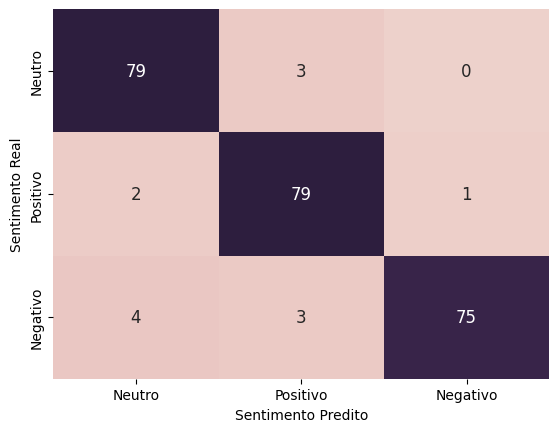

              precision    recall  f1-score   support

      Neutro       0.93      0.96      0.95        82
    Positivo       0.93      0.96      0.95        82
    Negativo       0.99      0.91      0.95        82

    accuracy                           0.95       246
   macro avg       0.95      0.95      0.95       246
weighted avg       0.95      0.95      0.95       246



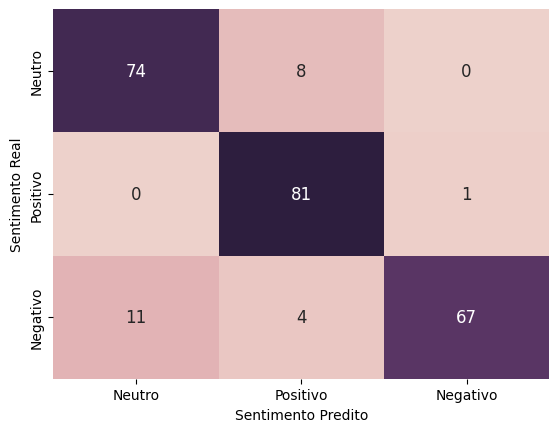

              precision    recall  f1-score   support

      Neutro       0.87      0.90      0.89        82
    Positivo       0.87      0.99      0.93        82
    Negativo       0.99      0.82      0.89        82

    accuracy                           0.90       246
   macro avg       0.91      0.90      0.90       246
weighted avg       0.91      0.90      0.90       246



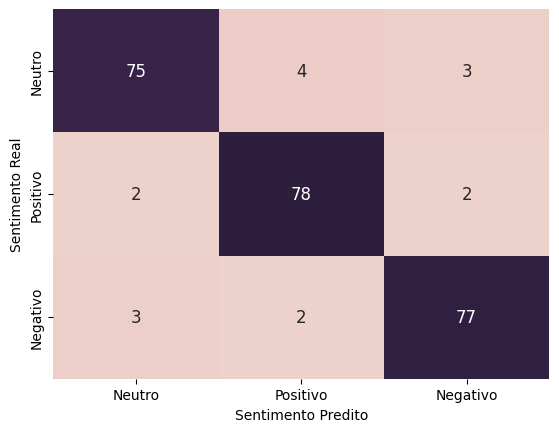

              precision    recall  f1-score   support

      Neutro       0.94      0.91      0.93        82
    Positivo       0.93      0.95      0.94        82
    Negativo       0.94      0.94      0.94        82

    accuracy                           0.93       246
   macro avg       0.94      0.93      0.93       246
weighted avg       0.94      0.93      0.93       246



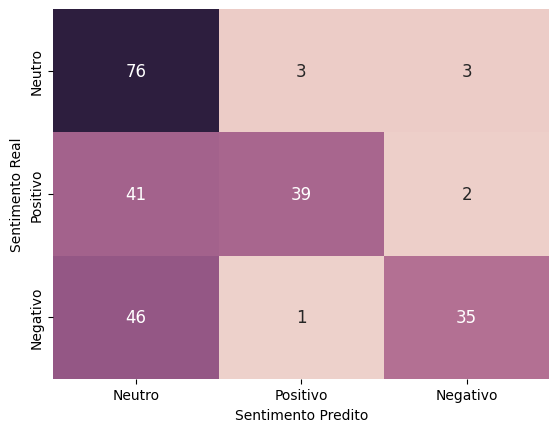

              precision    recall  f1-score   support

      Neutro       0.47      0.93      0.62        82
    Positivo       0.91      0.48      0.62        82
    Negativo       0.88      0.43      0.57        82

    accuracy                           0.61       246
   macro avg       0.75      0.61      0.61       246
weighted avg       0.75      0.61      0.61       246



In [37]:
metrics_df = pd.DataFrame()
for i in range(1, 5):
    model = f"model{i}"
    predicted_labels = dataset[f"predicted_sentiment_m{i}"]

    show_confusion_matrix(true_labels, predicted_labels)

    print(
        classification_report(
            true_labels,
            predicted_labels,
            target_names=["Neutro", "Positivo", "Negativo"],
        )
    )

    class_report = classification_report(
        true_labels,
        predicted_labels,
        target_names=["Neutro", "Positivo", "Negativo"],
        output_dict=True,
    )

    temp_df = pd.DataFrame(
        {
            "model": [model] * 3,
            "class": ["Positivo", "Negativo", "Neutro"],
            "f1_score": [
                round(class_report["Positivo"]["f1-score"], 2),
                round(class_report["Negativo"]["f1-score"], 2),
                round(class_report["Neutro"]["f1-score"], 2),
            ],
        }
    )
    metrics_df = pd.concat([metrics_df, temp_df], ignore_index=True)

In [38]:
metrics_df

,model,class,f1_score
0,model1,Positivo,0.95
1,model1,Negativo,0.95
2,model1,Neutro,0.95
3,model2,Positivo,0.93
4,model2,Negativo,0.89
5,model2,Neutro,0.89
6,model3,Positivo,0.94
7,model3,Negativo,0.94
8,model3,Neutro,0.93
9,model4,Positivo,0.62


In [39]:
metrics_df["model"] = metrics_df["model"].replace(
    {
        "model1": "Modelo A",
        "model2": "Modelo B",
        "model3": "Modelo C",
        "model4": "Modelo X",
    }
)

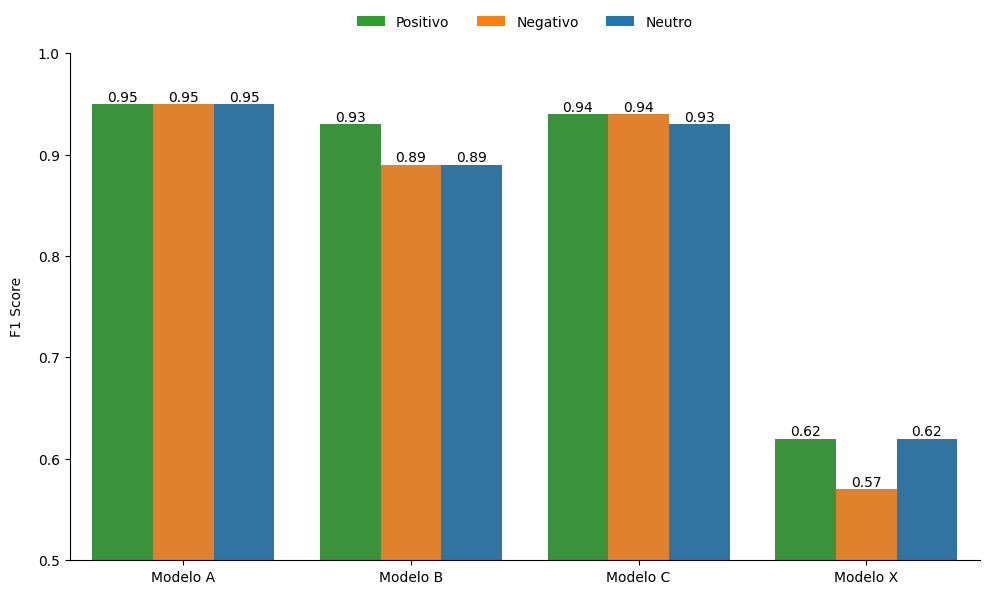

In [40]:
fig, ax = plt.subplots(1, figsize=(10, 6))

bars = sns.barplot(
    data=metrics_df,
    x="model",
    y="f1_score",
    hue="class",
    # width=0.9,
    ax=ax,
    palette=[
        POSITIVE_SENTIMENT_COLOR,
        NEGATIVE_SENTIMENT_COLOR,
        NEUTRAL_SENTIMENT_COLOR,
    ],
)

for i, p in enumerate(bars.patches):
    height = p.get_height()
    if math.isnan(height):
        height = 0.0

    # fontweight = "normal" if (i + 1) % 4 != 0 else "bold"
    fontweight = "normal"
    bars.annotate(
        text=f"{height:.2f}",
        xy=(p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="center",
        fontsize=10,
        fontweight=fontweight,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

ax.set_title(
    label="",
    # label="Comparação de performance dos modelos",
    fontsize=14,
    y=1.1,
)

ax.set_xlabel("")

# labels = ax.get_xticklabels()
# labels[-1].set_fontweight("bold")
# ax.set_xticklabels(labels)

# ax.set_yticks([])
ax.set_ylabel("F1 Score", labelpad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)

ax.set_ylim(0.5, 1.0)

positive_patch = plt.Rectangle((0, 0), 1, 1, fc=POSITIVE_SENTIMENT_COLOR)
negative_patch = plt.Rectangle((0, 0), 1, 1, fc=NEGATIVE_SENTIMENT_COLOR)
neutral_patch = plt.Rectangle((0, 0), 1, 1, fc=NEUTRAL_SENTIMENT_COLOR)

ax.legend(
    # title="",
    handles=[positive_patch, negative_patch, neutral_patch],
    labels=PLOT_SENTIMENT_LABELS,
    bbox_to_anchor=(0.5, 1.1),
    loc="upper center",
    edgecolor="1",
    ncols=3,
)

plt.savefig(
    "models_performance_comparison.png",
    transparent=False,
    dpi=300,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()